# PDF analysis

Here I am interested in the PDF studies that Mingshu has performed in his turbulent BEC experiments.  The basic challenge is to take the observed pdf (with fat wings) and separate that from the also measured pdf for a BEC alone.

In [1]:
import PyPlot as plt
import FFTW
import Random
import Statistics as Stat
import StatsBase
using LaTeXStrings
using LsqFit
using NPZ
using DSP

In [2]:
# A simple gauss model
@. gauss_model(x, p) = p[1] * exp(-(((x - p[2]) / p[3])^2) / 2)

"""
A callable struct to implement a Julia equivalent of a closure

This makes a Guass*poly of order 
"""
struct Gauss
    order::Int64
end

function (a::Gauss)(x, p)
    ans = ones(Float64, size(x))

    for n in 1:a.order
        ans .+= p[n+3] .* x .^ n
    end

    return ans .* gauss_model(x, p)
end

## Import the data

In [5]:
v_bec = npzread("pdf_BEC_list_long.npy") # Mislabeled
# v_bec = npzread("pdf_BEC_list_long0.npy");

println(length(v_bec))

v_bec_hist = Stat.normalize(StatsBase.fit(StatsBase.Histogram, v_bec, range(-5.39, 5.39, 50)))

1770


StatsBase.Histogram{Float64, 1, Tuple{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}}
edges:
  -5.39:0.22:5.39
weights: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
closed: left
isdensity: true

In [6]:
# From Mingshu directly
v_bec_hist_data =[0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.004329,
    0.01298701, 0.02164502, 0.04329004, 0.0995671, 0.19480519,
    0.29004329, 0.49350649, 0.75324675, 0.94805195, 1.0,
    0.99134199, 0.92640693, 0.65800866, 0.51082251, 0.33333333,
    0.21212121, 0.08658009, 0.05627706, 0.01731602, 0.0,
    0.00865801, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0]

v_bec_hist_data ./= sum(v_bec_hist_data)


v_bec_hist_x = [-5.39, -5.17, -4.95, -4.73, -4.51, -4.29, -4.07, -3.85, -3.63,
    -3.41, -3.19, -2.97, -2.75, -2.53, -2.31, -2.09, -1.87, -1.65,
    -1.43, -1.21, -0.99, -0.77, -0.55, -0.33, -0.11, 0.11, 0.33,
    0.55, 0.77, 0.99, 1.21, 1.43, 1.65, 1.87, 2.09, 2.31,
    2.53, 2.75, 2.97, 3.19, 3.41, 3.63, 3.85, 4.07, 4.29,
    4.51, 4.73, 4.95, 5.17, 5.39]

v_turb_hist_data =[0.0, 0.0, 0.00123153, 0.0, 0.0,
    0.0, 0.00123153, 0.00492611, 0.00369458, 0.00615764,
    0.01108374, 0.01724138, 0.0270936, 0.05418719, 0.091133,
    0.13054187, 0.20812808, 0.31034483, 0.38054187, 0.50738916,
    0.64162562, 0.84359606, 0.87931034, 1.0, 0.97783251,
    0.93965517, 0.89655172, 0.72044335, 0.62192118, 0.46305419,
    0.32389163, 0.22906404, 0.16871921, 0.11699507, 0.08251232,
    0.05541872, 0.03817734, 0.01600985, 0.02339901, 0.00862069,
    0.00369458, 0.00246305, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0]

v_turb_hist_data ./= sum(v_turb_hist_data)

v_turb_hist_x = [-5.39, -5.17, -4.95, -4.73, -4.51, -4.29, -4.07, -3.85, -3.63,
    -3.41, -3.19, -2.97, -2.75, -2.53, -2.31, -2.09, -1.87, -1.65,
    -1.43, -1.21, -0.99, -0.77, -0.55, -0.33, -0.11, 0.11, 0.33,
    0.55, 0.77, 0.99, 1.21, 1.43, 1.65, 1.87, 2.09, 2.31,
    2.53, 2.75, 2.97, 3.19, 3.41, 3.63, 3.85, 4.07, 4.29,
    4.51, 4.73, 4.95, 5.17, 5.39];

In [291]:
# Workout the number of data point that must have been used for the turb data set

w =1 / minimum( [d for d in v_turb_hist_data if d > 0] )

8775.979277808903

## Simple fit and deconv.

In [8]:
# Fit turbulant data to poly gauss_model
gauss_model_bec = Gauss(0)

p0 = [1.1, 0.0, 1.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1, -1]
ub = [10.0, 0.5, 10, 1.0, 1.0]

p0 = [1.1, 0.0, 1.0]
lb = [0.1, -0.5, 0.01]
ub = [10.0, 0.5, 10]

# There are 1770 points in the BEC dataset
n = 1770.0
w_bec = [(d * n  + 1 )^-0.5 for d in v_bec_hist_data] .* n
bec_fit = LsqFit.curve_fit(gauss_model_bec, v_bec_hist_x, v_bec_hist_data, w_bec, p0, lower=lb, upper=ub);

# Fit turbulant data to poly gauss_model
gauss_model_turb = Gauss(6)
p0 = [1.1, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
ub = [10.0, 0.5, 10, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# There are 8776 points in the turb dataset
n = 8776.0
w_turb = [(n * d + 1)^-0.5 for d in v_turb_hist_data] .* n
turb_fit = LsqFit.curve_fit(gauss_model_turb, v_turb_hist_x, v_turb_hist_data, w_turb, p0, lower=lb, upper=ub);

In [9]:
display(LsqFit.coef(bec_fit))
display(LsqFit.coef(turb_fit))


3-element Vector{Float64}:
  0.1334846687037756
 -0.003331270980782114
  0.6548981990714353

9-element Vector{Float64}:
  0.10406160858323153
 -0.5
  0.9765326143104411
  0.34884726220595974
 -0.039924877036883105
 -0.04153097887503716
  0.02053652134459942
  0.015209901364476908
  0.0023409467999482726

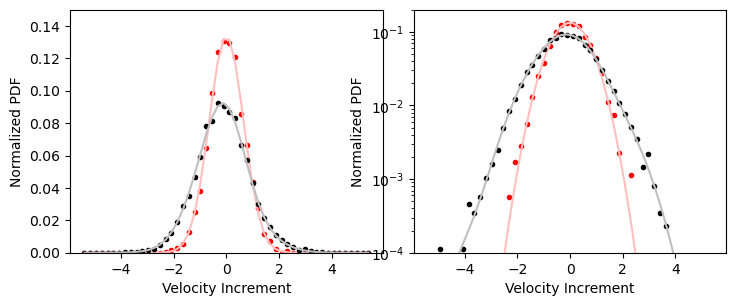

In [10]:
# Plot the PDFs as well as the fit

fig = plt.figure(figsize=Tuple([8, 3]))
ax_dict = fig.subplot_mosaic(
    "AB",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.1,
        "hspace" => 0.4,
    ),
)

# w = [sqrt(d) for d in v_bec_hist_data] ./ 20

# ax_dict["A"].errorbar(v_bec_hist_x, v_bec_hist_data, yerr=w, fmt="r.")
ax_dict["A"].plot(v_bec_hist_x, v_bec_hist_data, "r.")
ax_dict["A"].plot(v_bec_hist_x, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), "-", color=(1.0, 0.75, 0.75))

ax_dict["A"].plot(v_turb_hist_x, v_turb_hist_data, "k.")
ax_dict["A"].plot(v_turb_hist_x, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), "-", color=(0.75, 0.75, 0.75))

ax_dict["A"].set_xlabel("Velocity Increment")
ax_dict["A"].set_ylabel("Normalized PDF")
ax_dict["A"].set_ylim([0, 0.15])

ax_dict["B"].plot(v_bec_hist_x, v_bec_hist_data, "r.")
ax_dict["B"].plot(v_bec_hist_x, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), "-", color=(1.0, 0.75, 0.75))

ax_dict["B"].plot(v_turb_hist_x, v_turb_hist_data, "k.")
ax_dict["B"].plot(v_turb_hist_x, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), "-", color=(0.75, 0.75, 0.75))

ax_dict["B"].set_xlabel("Velocity Increment")
ax_dict["B"].set_ylabel("Normalized PDF")
ax_dict["B"].set_yscale("log")
ax_dict["B"].set_ylim([1e-4, 0.2])

plt.gcf()


In [16]:
reg = 0.1

# Now I will zero pad both data sets

pad = [0.0 for x in v_bec_hist_data]

v_bec_hist_pad = vcat(pad, gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit)), pad) # Use the fit here
v_turb_hist_pad = vcat(pad, gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit)), pad)

# Now I compute the FFT of these

v_bec_hist_fft = FFTW.fft(v_bec_hist_pad)
v_turb_hist_fft = FFTW.fft(v_turb_hist_pad)

conv_fft = v_turb_hist_fft .* v_bec_hist_fft
deconv_fft = v_turb_hist_fft .* conj(v_bec_hist_fft) ./ (reg .+ abs.(v_bec_hist_fft) .^ 2)

conv = FFTW.fftshift(real(FFTW.ifft(conv_fft)))
deconv = FFTW.fftshift(real(FFTW.ifft(deconv_fft)))

# Remove zero-padding
conv = conv[(length(v_bec_hist_data)+1):(2*length(v_bec_hist_data))]
deconv = deconv[(length(v_bec_hist_data)+1):(2*length(v_bec_hist_data))]

sum(deconv)


0.9112697700578493

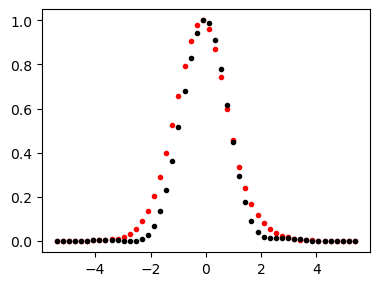

In [19]:
fig = plt.figure(figsize=Tuple([4, 3]))
ax_dict = fig.subplot_mosaic(
    "A",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.1,
        "hspace" => 0.4,
    ),
)

m = gauss_model_turb(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, m ./ maximum(m), "r.")
ax_dict["A"].plot(v_turb_hist_x, deconv ./ maximum(deconv), "k.")
# ax_dict["A"].set_yscale("log")

plt.gcf()


## Now fit to the the deconvolved PDF

The title is a bit unclear.  Here I will be making my fit function perform the convolve operation and fitting to the sort of polynomial model that I used above to fit to the observed PDF.

In [309]:
struct ConvolveGauss{T}
    model::T
    kernel::Vector{Float64}
end

function (a::ConvolveGauss)(y, p)

    

    # Evaluate model
    m = a.model
    d = m(y, p)

    pad = zeros(size(y))

    # The zero padding doesn't seem to matter 
    d = vcat(pad, d, pad) 
    k = vcat(pad, a.kernel, pad)

    # Convolve with kernel
    d_fft = FFTW.fft(d)
    kernel_fft = FFTW.fft(k) # This can and should be cached
    conv_fft = d_fft .* kernel_fft
    conv = FFTW.fftshift(real(FFTW.ifft(conv_fft)))


    conv = conv[(length(y)+1):(2*length(y))]

    return conv
    # println(typeof(d), " , ", typeof(a.kernel))
    # return DSP.conv(d, a.kernel)
end

In [310]:
bec_fit_temp

3-element Vector{Float64}:
  0.1334846687037756
 -0.003331270980782114
  0.6548981990714353

In [311]:
# Fit turbulant data to conv_model
model = Gauss(4)
bec_fit_temp = copy(LsqFit.coef(bec_fit))
# bec_fit_temp[2] = 0.25 # This was testing if changing this caused the recovered peak to move in the correct direction (it did)

conv_model = ConvolveGauss(model, gauss_model_bec(v_bec_hist_x, bec_fit_temp));
# conv_model = ConvolveGauss(model, v_bec_hist_data); # This convolves with the actual data.

p0 = [1.1, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
lb = [0.1, -0.5, 0.01, -1.0, -1.0, -1.0, -1.0]
ub = [10.0, 0.5, 10, 1.0, 1.0, 1.0, 1.0]

# There are 8776 points in the turb dataset
n = 1.0 / 8776.0
w_turb = [(n * d + 1)^-0.5 for d in v_turb_hist_data] ./ n
turb_fit = LsqFit.curve_fit(conv_model, v_turb_hist_x, v_turb_hist_data, w_turb, p0, lower=lb, upper=ub);
LsqFit.coef(turb_fit)

7-element Vector{Float64}:
  0.14068291461652313
  0.17806976112662348
  0.7149702998148953
 -0.303646524741756
 -0.40469958450241045
 -0.07967366268019649
  0.19558144935977628

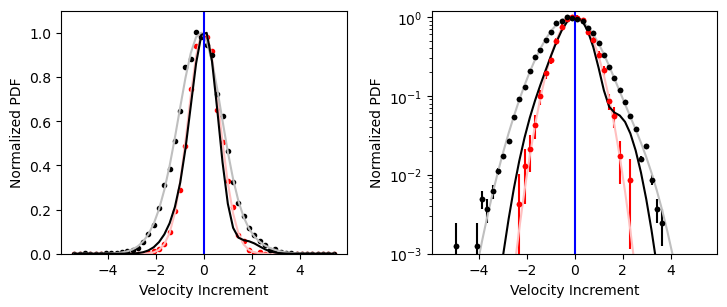

In [312]:
# Plot the PDFs as well as the fit

fig = plt.figure(figsize=Tuple([8, 3]))
ax_dict = fig.subplot_mosaic(
    "AB",
    gridspec_kw=Dict(
        "bottom" => 0.12,
        "top" => 0.93,
        "left" => 0.15,
        "right" => 0.97,
        "wspace" => 0.3,
        "hspace" => 0.4,
    ),
)

m = gauss_model_bec(v_bec_hist_x, LsqFit.coef(bec_fit))

# ax_dict["A"].errorbar(v_bec_hist_x, v_bec_hist_data ./ maximum(m), yerr=(1.0./w_bec)./ maximum(m), fmt="r.")
ax_dict["A"].plot(v_bec_hist_x, v_bec_hist_data ./ maximum(m), "r.")
ax_dict["A"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

e_bec = (1.0./w_bec) .* [d > 0 ? 1.0 : 0.0 for d in v_bec_hist_data]
ax_dict["B"].errorbar(v_bec_hist_x, v_bec_hist_data ./ maximum(m), yerr=e_bec ./ maximum(m), fmt="r.")
ax_dict["B"].plot(v_bec_hist_x, v_bec_hist_data ./ maximum(m), "r.")
ax_dict["B"].plot(v_bec_hist_x, m ./ maximum(m), "-", color=(1.0, 0.75, 0.75))

m = conv_model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, v_turb_hist_data ./ maximum(m) , "k.")
ax_dict["A"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

e_turb = (1.0./w_turb) .* [d > 0 ? 1.0 : 0.0 for d in v_turb_hist_data]
ax_dict["B"].errorbar(v_turb_hist_x, v_turb_hist_data ./ maximum(m), yerr=e_turb ./ maximum(m), fmt="k.")
ax_dict["B"].plot(v_turb_hist_x, v_turb_hist_data ./ maximum(m) , "k.")
ax_dict["B"].plot(v_turb_hist_x, m ./ maximum(m) , "-", color=(0.75, 0.75, 0.75))

m = model(v_turb_hist_x, LsqFit.coef(turb_fit))
ax_dict["A"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")
ax_dict["B"].plot(v_turb_hist_x, model(v_turb_hist_x, LsqFit.coef(turb_fit)) ./ maximum(m), "-", color="k")


ax_dict["A"].set_xlabel("Velocity Increment")
ax_dict["B"].set_xlabel("Velocity Increment")

ax_dict["A"].set_ylabel("Normalized PDF")
ax_dict["B"].set_ylabel("Normalized PDF")

ax_dict["A"].axvline(0.0, color="b")
ax_dict["B"].axvline(0.0, color="b")


# ax_dict["A"].set_xlim([-1.5, 1.5])
ax_dict["B"].set_yscale("log")

ax_dict["A"].set_ylim([0, 1.1])
ax_dict["B"].set_ylim([1e-3, 1.2])

plt.gcf()
